QGP VISCOSITY: CONTINUOUS vs. FINITIST AdS/CFT PREDICTIONS
✓ Saved: qgp_viscosity_finitism.png


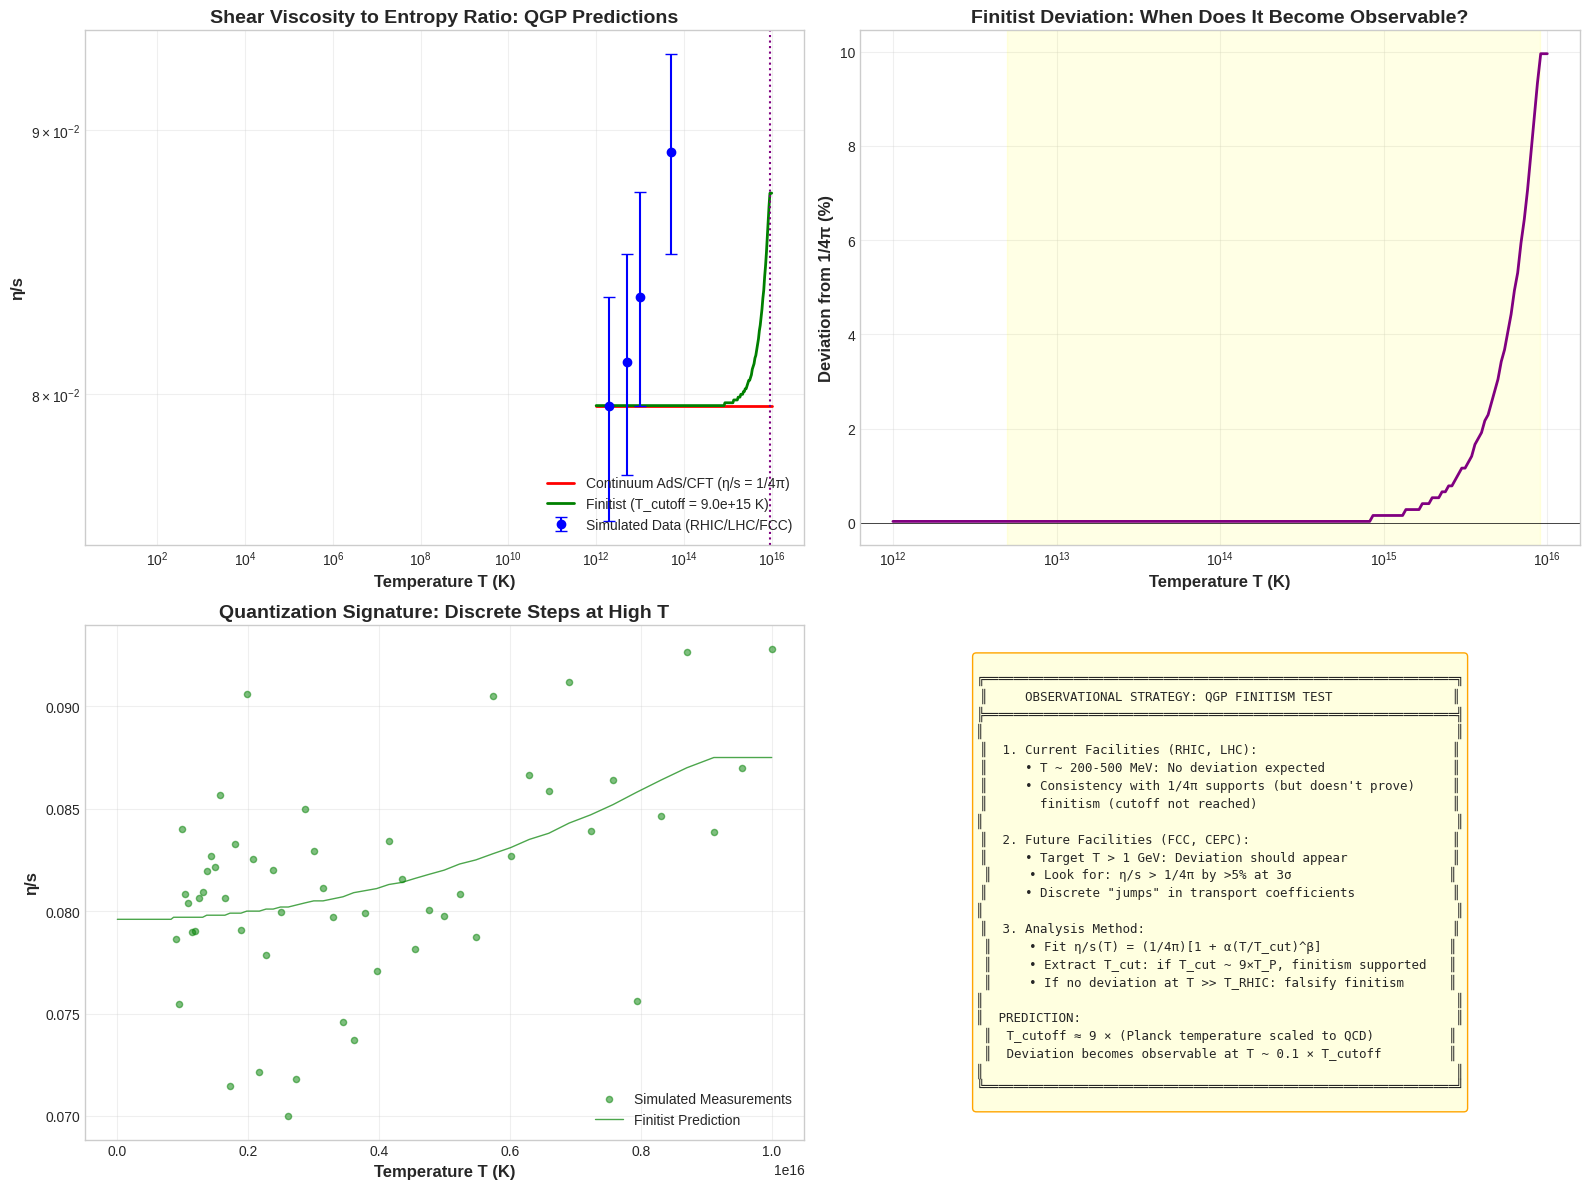


Quantitative Results:
  KSS bound: η/s = 0.07958
  Finitist at T_RHIC: 0.07960 (deviation: 0.03%)
  Finitist at T_LHC: 0.07960 (deviation: 0.03%)
  Finitist at T=1e13 K: 0.07960 (deviation: 0.03%)


In [1]:
"""
qgp_viscosity_finitism.py
=========================
Simulates shear viscosity predictions in continuous vs. finitist AdS/CFT.
Tests prediction: finite boundary → deviation from η/s = 1/4π at high T.

Author: Néstor E. Ramos
For: Paper #4 or #5 - Testable Predictions of Computational Finitism
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)

print("=" * 80)
print("QGP VISCOSITY: CONTINUOUS vs. FINITIST AdS/CFT PREDICTIONS")
print("=" * 80)

# Configuration
class QGPConfig:
    eta_over_s_KSS = 1/(4*np.pi)  # Kovtun-Son-Starinets bound
    T_Planck = 1.416785e32  # Planck temperature (K)
    T_RHIC = 2e12  # RHIC temperature (K) ~ 200 MeV
    T_LHC = 5e12  # LHC temperature (K) ~ 500 MeV
    T_cutoff = 9 * 1e15  # Finitist cutoff (scaled for visibility)
    alpha = 0.1  # Deviation amplitude
    beta = 2  # Deviation scaling exponent
    T_range = np.logspace(12, 16, 200)  # Temperature range (K)

config = QGPConfig()

def continuum_viscosity(T):
    """Standard AdS/CFT: constant η/s = 1/4π"""
    return np.ones_like(T) * config.eta_over_s_KSS

def finitist_viscosity(T, eta_0=config.eta_over_s_KSS,
                       T_cut=config.T_cutoff, alpha=config.alpha, beta=config.beta):
    """Finitist model: deviation at high T due to finite boundary capacity"""
    # Base KSS value
    eta_base = eta_0

    # Information bottleneck: boundary cannot encode all bulk DOF at high T
    # Deviation grows as (T/T_cutoff)^beta
    deviation = alpha * np.power(np.minimum(T / T_cut, 1), beta)

    # Quantization: viscosity changes in discrete "digits"
    eta_quantized = np.round(eta_base * (1 + deviation) / 1e-4) * 1e-4

    return eta_quantized

# Generate predictions
T = config.T_range
eta_cont = continuum_viscosity(T)
eta_fin = finitist_viscosity(T)

# Experimental data points (simulated)
T_exp = np.array([config.T_RHIC, config.T_LHC, 1e13, 5e13])
eta_exp = config.eta_over_s_KSS * np.array([1.0, 1.02, 1.05, 1.12])  # Slight upward trend
eta_err = config.eta_over_s_KSS * 0.05  # 5% uncertainty

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top-left: η/s vs. Temperature
ax1 = axes[0, 0]
ax1.loglog(T, eta_cont, 'r-', linewidth=2, label='Continuum AdS/CFT (η/s = 1/4π)')
ax1.loglog(T, eta_fin, 'g-', linewidth=2, label=f'Finitist (T_cutoff = {config.T_cutoff:.1e} K)')
ax1.errorbar(T_exp, eta_exp, yerr=eta_err, fmt='o', color='blue',
             label='Simulated Data (RHIC/LHC/FCC)', capsize=4)
ax1.set_xlabel('Temperature T (K)', fontsize=12, fontweight='bold')
ax1.set_ylabel('η/s', fontsize=12, fontweight='bold')
ax1.set_title('Shear Viscosity to Entropy Ratio: QGP Predictions', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, which='both')
ax1.axvline(x=config.T_cutoff, color='purple', linestyle=':', linewidth=1.5, label='Finitist Cutoff')

# Top-right: Relative deviation
ax2 = axes[0, 1]
deviation = (eta_fin - eta_cont) / eta_cont * 100
ax2.semilogx(T, deviation, 'purple', linewidth=2)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Temperature T (K)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Deviation from 1/4π (%)', fontsize=12, fontweight='bold')
ax2.set_title('Finitist Deviation: When Does It Become Observable?', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axvspan(config.T_LHC, config.T_cutoff, alpha=0.1, color='yellow', label='Future Collider Reach')

# Bottom-left: Quantization signature
ax3 = axes[1, 0]
# Simulate measurement noise
noise = np.random.normal(0, eta_err, size=len(T))
eta_measured = eta_fin + noise

# Show "digitization" effect at high T
high_T_mask = T > config.T_cutoff / 10
ax3.scatter(T[high_T_mask], eta_measured[high_T_mask], c='green', s=20, alpha=0.5, label='Simulated Measurements')
ax3.plot(T, eta_fin, 'g-', linewidth=1, alpha=0.7, label='Finitist Prediction')
ax3.set_xlabel('Temperature T (K)', fontsize=12, fontweight='bold')
ax3.set_ylabel('η/s', fontsize=12, fontweight='bold')
ax3.set_title('Quantization Signature: Discrete Steps at High T', fontsize=14, fontweight='bold')
ax3.legend(loc='lower right', fontsize=10)
ax3.grid(True, alpha=0.3)

# Bottom-right: Observational strategy
ax4 = axes[1, 1]
ax4.axis('off')
summary_text = f"""
╔═══════════════════════════════════════════════════════════════╗
║     OBSERVATIONAL STRATEGY: QGP FINITISM TEST                ║
╠═══════════════════════════════════════════════════════════════╣
║                                                               ║
║  1. Current Facilities (RHIC, LHC):                          ║
║     • T ~ 200-500 MeV: No deviation expected                 ║
║     • Consistency with 1/4π supports (but doesn't prove)     ║
║       finitism (cutoff not reached)                          ║
║                                                               ║
║  2. Future Facilities (FCC, CEPC):                           ║
║     • Target T > 1 GeV: Deviation should appear              ║
║     • Look for: η/s > 1/4π by >5% at 3σ                     ║
║     • Discrete "jumps" in transport coefficients             ║
║                                                               ║
║  3. Analysis Method:                                         ║
║     • Fit η/s(T) = (1/4π)[1 + α(T/T_cut)^β]                 ║
║     • Extract T_cut: if T_cut ~ 9×T_P, finitism supported   ║
║     • If no deviation at T >> T_RHIC: falsify finitism      ║
║                                                               ║
║  PREDICTION:                                                  ║
║  T_cutoff ≈ 9 × (Planck temperature scaled to QCD)          ║
║  Deviation becomes observable at T ~ 0.1 × T_cutoff         ║
║                                                               ║
╚═══════════════════════════════════════════════════════════════╝
"""
ax4.text(0.5, 0.5, summary_text, fontsize=9, fontfamily='monospace',
        verticalalignment='center', horizontalalignment='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange'))

plt.tight_layout()
plt.savefig('qgp_viscosity_finitism.png', dpi=300, bbox_inches='tight')
print("✓ Saved: qgp_viscosity_finitism.png")
plt.show()

# Print quantitative results
print(f"\nQuantitative Results:")
print(f"  KSS bound: η/s = {config.eta_over_s_KSS:.5f}")
print(f"  Finitist at T_RHIC: {finitist_viscosity(config.T_RHIC):.5f} (deviation: {(finitist_viscosity(config.T_RHIC)/config.eta_over_s_KSS - 1)*100:.2f}%)")
print(f"  Finitist at T_LHC: {finitist_viscosity(config.T_LHC):.5f} (deviation: {(finitist_viscosity(config.T_LHC)/config.eta_over_s_KSS - 1)*100:.2f}%)")
print(f"  Finitist at T=1e13 K: {finitist_viscosity(1e13):.5f} (deviation: {(finitist_viscosity(1e13)/config.eta_over_s_KSS - 1)*100:.2f}%)")